# 공유폴더에 접근하기






In [ ]:
# 구글 드라이브 마운트

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset.zip" -d "/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/"

unzip:  cannot find or open /content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset.zip, /content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset.zip.zip or /content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset.zip.ZIP.


In [ ]:
root_dir = '/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset'




# 데이터 준비 및 전처리

**COVID-CT-Dataset: A CT Image Dataset about COVID-19**

[Original data source](https://github.com/UCSD-AI4H/COVID-CT)

[Related paper](https://arxiv.org/pdf/2003.13865.pdf)

### 이미지 예시 출력

In [ ]:
import random
import os
import cv2
import matplotlib.pyplot as plt

### 데이터 분포 확인

In [ ]:
import os

In [ ]:
def print_files_in_dir(root_dir, prefix):
    files = os.listdir(root_dir)
    lab = ['COVID', "Non-COVID"]
    for i, file in enumerate(files):
        path = os.path.join(root_dir, file)
        file_list = os.listdir(path)
        print(f"{prefix} 데이터의 {lab[i]} 수: {len(file_list)}")

        # print(f"해당 폴더의 데이터의 수 {len(file_list)}")

In [ ]:
phase = "Train"
# root_dir 문자열 바로 뒤에 슬래시(/)를 추가하여 경로를 완성합니다.
print_files_in_dir(root_dir + f"/Covid_{phase}", phase)
print()

phase = "Valid"
print_files_in_dir(root_dir + f"/Covid_{phase}", phase)
print()

phase = "Test"
print_files_in_dir(root_dir + f"/Covid_{phase}", phase)

Train 데이터의 COVID 수: 191
Train 데이터의 Non-COVID 수: 234

Valid 데이터의 COVID 수: 60
Valid 데이터의 Non-COVID 수: 58

Test 데이터의 COVID 수: 98
Test 데이터의 Non-COVID 수: 105


### 데이터 전처리

In [ ]:
# 필요한 모듈 불러오기

import numpy as np
import torch
from torchvision import datasets, transforms
import torch.utils.data as data

In [ ]:
# 디바이스 설정 (GPU 사용 가능하면 GPU 사용하도록)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

random_seed = 2022

torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)

np.random.seed(random_seed)
random.seed(random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# 데이터 transform 적용하기

normalize = transforms.Normalize(mean=[0,0,0], std=[1,1,1])
image_transforms = {
    'train': transforms.Compose([
    transforms.Resize(256),

    # data augmentation
    transforms.RandomResizedCrop((224),scale=(0.5,1.0)),
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
    normalize
    ]),

    'valid': transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
    ])
}

In [ ]:
train_dataset_folder = root_dir + 'Covid_Train'
val_dataset_folder = root_dir + 'Covid_Valid'
test_dataset_folder = root_dir + 'Covid_Test'

In [ ]:
# 슬래시(/)를 명시적으로 추가하거나 os.path.join을 사용하여 경로를 올바르게 이어줍니다.
train_dataset_folder = root_dir + '/Covid_Train'
val_dataset_folder = root_dir + '/Covid_Valid'
test_dataset_folder = root_dir + '/Covid_Test'

# 위 코드를 다시 실행하신 후 아래 데이터셋 객체를 다시 생성해 보세요.
train_dataset = datasets.ImageFolder(root=train_dataset_folder, transform=image_transforms['train'])
valid_dataset = datasets.ImageFolder(root=val_dataset_folder, transform=image_transforms['valid'])
test_dataset = datasets.ImageFolder(root=test_dataset_folder, transform=image_transforms['valid'])

In [ ]:
# DataLoader을 위한 hyperparameter 설정

train_params = {
    'batch_size': 64,
    'shuffle': True,
    'num_workers': 1,
    'drop_last': False}

valid_params = {
    'batch_size': 64,
    'shuffle': False,
    'num_workers': 1,
    'drop_last': False}

In [ ]:
train_loader = data.DataLoader(train_dataset, **train_params)
valid_loader = data.DataLoader(valid_dataset, **valid_params)
test_loader = data.DataLoader(test_dataset, **valid_params)

In [ ]:
# Train DataLoader 데이터 확인해보기

for x, y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64])


In [ ]:
# Valid DataLoader 데이터 확인해보기

for x, y in valid_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64])




---


#워크플로우
### 1. 구조 상세: 전체 모델 아키텍처 (CombinedCovidNet)

가장 핵심이 되는 부분으로, 두 가지 다른 시야를 가진 신경망을 하나로 합친 융합 모델(Feature Fusion)을 사용하고 있습니다.

* **CustomFeatureExtractor (맞춤형 특징 추출기):** `ResidualBlock`(잔차 연결)을 활용하여 깊은 층에서도 학습이 잘 되도록 설계되었습니다. 합성곱(Conv), 배치 정규화(BatchNorm), ReLU 활성화 함수 순서로 구성되어 학습을 안정화합니다. 최종적으로 `AdaptiveAvgPool2d((1, 1))`을 통해 28x28의 해상도를 1x1로 압축하여, 연산량을 줄이고 과적합을 방지하는 128개의 핵심 특징을 추출합니다.


* **ResNet50 전이 학습 (Transfer Learning):** 수백만 장의 데이터로 미리 학습된 `models.resnet50(pretrained=True)` 모델을 뼈대로 가져옵니다. 기존의 1000개 클래스 분류기 층을 잘라내어 2048개의 굵직한 특징 벡터만 추출하도록 설정했습니다.


* **특징 융합 및 최종 분류기:** 모델의 `forward` 과정에서 `torch.cat`을 이용해 ResNet50의 2048개 특징과 Custom 모델의 128개 특징을 하나로 이어 붙입니다. 총 2176개의 특징이 `Dropout`(과적합 억제)을 거쳐 최종 `Linear` 층으로 들어가 COVID와 Non-COVID 2개의 클래스로 분류됩니다.

<br>

### 2. 하이퍼파라미터 튜닝 (Optuna)

모델이 학습을 시작하기 전, 최적의 셋팅값을 찾기 위해 `Optuna` 라이브러리를 활용하여 모의고사를 진행합니다.

* **탐색 공간 설정:** 학습률(`lr`)과 L2 규제인 가중치 감쇠(`weight_decay`)는 1e-5에서 1e-2 사이의 로그 스케일(`log=True`)로 탐색하고, 드롭아웃 비율(`dropout_p`)은 0.1에서 0.5 사이로 탐색합니다.


* **효율적인 탐색 (Pruning):** 총 10번의 시도(`n_trials=10`)를 10 에포크씩 진행하되, `MedianPruner`를 도입하여 가망이 없는 시도(이전 시도들의 중간값보다 성능이 낮은 경우)는 도중에 잘라내어 탐색 시간을 단축합니다.


* **목적 함수:** 검증 데이터의 손실(`avg_val_loss`)을 '최소화(minimize)'하는 방향으로 최적의 파라미터 조합을 찾습니다.

<br>

### 3. 최종 모델 학습 (Final Training)

Optuna가 찾아낸 최고 셋팅값을 바탕으로 본격적인 실전 학습을 진행합니다.

* **최적값 적용:** 앞서 찾은 최적의 학습률, 가중치 감쇠, 드롭아웃 비율을 `CombinedCovidNet`과 `Adam` 옵티마이저에 주입합니다. 손실 함수로는 `CrossEntropyLoss`를 사용합니다.


* **학습 루프 및 Early Stopping:** 총 30 에포크(`train_epoch = 30`)로 넉넉하게 학습을 설정합니다. 매 에포크마다 훈련 손실과 검증 손실을 계산하며, 검증 손실(`avg_val_loss`)이 이전 최저치보다 낮아지면 `copy.deepcopy`를 이용해 베스트 모델을 갱신합니다.


* **조기 종료:** 융합 모델이 미니배치 노이즈에 견딜 수 있도록 인내심(`patience=10`)을 부여했으며, 10 에포크 연속으로 검증 손실이 개선되지 않으면 과적합을 막기 위해 학습을 강제로 멈춥니다.

<br>

### 4. 모델 테스트 및 평가 (Evaluation)

학습이 끝난 후, 저장해둔 `model_best`를 불러와 한 번도 보지 못한 테스트 데이터(`test_loader`)로 최종 성능을 평가합니다.

* **예측 및 지표 계산:** 모델의 출력값에 `argmax`를 취해 예측 클래스를 구하고, `Softmax`로 확률(score)을 계산합니다. 이를 바탕으로 `sklearn.metrics`를 활용해 정확도(Accuracy), 민감도(Sensitivity/Recall), 특이도(Specificity), ROC AUC 점수를 계산합니다.


* **결과 시각화:** X축을 False Positive Rate, Y축을 True Positive Rate로 하는 `ROC Curve`를 그려 모델의 판별 능력을 직관적으로 확인합니다. 또한 `seaborn` 라이브러리를 통해 예측값과 실제 정답을 대조하는 혼동 행렬(Confusion Matrix) 히트맵을 그려, 모델이 구체적으로 어떤 클래스에서 헷갈렸는지 시각적으로 분석합니다.



---



# 1. 모델 만들기

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# 1. Custom 특징 추출기 (잔차 블록 포함)
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        out = F.relu(out)
        return out

class CustomFeatureExtractor(nn.Module):
    def __init__(self):
        super(CustomFeatureExtractor, self).__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.init_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.avgpool(x)
        x = x.flatten(start_dim=1) # 출력 크기: 128개의 특징
        return x


# 🌟 2. 두 모델을 하나로 결합한 최강의 융합 모델
class CombinedCovidNet(nn.Module):
    def __init__(self, num_classes=2, dropout_p=0.3):
        super(CombinedCovidNet, self).__init__()

        # A. 전이학습(ResNet50) 뼈대 가져오기 (마지막 분류기 층 제거)
        resnet = models.resnet50(pretrained=True)
        # ResNet50의 마지막 fc 층을 제외한 모든 층을 묶어서 특징 추출기로 사용
        self.resnet_features = nn.Sequential(*list(resnet.children())[:-1])

        # B. Custom 뼈대 가져오기
        self.custom_features = CustomFeatureExtractor()

        # C. 두 특징을 합친 최종 분류기 설계
        # ResNet50 특징(2048개) + Custom 특징(128개) = 총 2176개
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(2048 + 128, num_classes)
        )

    def forward(self, x):
        # 1. 이미지가 들어가서 두 모델의 뇌를 각각 거칩니다.
        res_out = self.resnet_features(x).flatten(start_dim=1)  # (Batch, 2048)
        custom_out = self.custom_features(x)                    # (Batch, 128)

        # 2. 융합 (Concatenation): 두 특징을 하나로 이어 붙입니다.
        combined_features = torch.cat((res_out, custom_out), dim=1) # (Batch, 2176)

        # 3. 최종 분류
        out = self.classifier(combined_features)
        return out

# 모델 생성 확인
model = CombinedCovidNet(num_classes=2)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


CombinedCovidNet(
  (resnet_features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
         

 이 아키텍처에 적용된 핵심 원리들.


1. Functional 방식의 활용: 직진만 하는 nn.Sequential 대신 nn.Module을 상속받아 데이터의 흐름을 자유롭게 설계하는 방식을 채택했습니다.  실무에서는 이 방식을 훨씬 더 많이 사용합니다.  
2. 잔차 연결 (Skip Connection): 네트워크가 깊어질수록 학습이 어려워지는 것을 막기 위해, forward 함수 내에서 identity = self.shortcut(x)로 원본 데이터를 저장한 후, 층의 연산 결과에 out += identity 형태로 더해주었습니다.  
3. 정규화 위치 최적화: Conv -> BatchNorm -> ReLU 순서로 배치했습니다.  비대칭 분포(음수 제거 후)를 정규화하게 되어 효과가 감소하는 역효과를 막고 학습을 안정화하기 위함입니다.  
4. Dropout (과적합 억제): 학습 과정에서 은닉층의 노드들을 무작위 비율(0.3)로 꺼버린 상태로 학습하여, 모델이 훈련 데이터에만 완벽하게 맞춰지는 과적합(Overfitting)을 억제하도록 설계했습니다.  
5. 깊어진 계층과 특징 추출얕은 층에서는 선이나 점 같은 기본적인 패턴을 감지하고, 층이 깊어짐에 따라 바퀴나 창문처럼 더 복잡한 형태의 객체를 인식할 수 있도록 모델의 용량(Capacity)을 확장했습니다.  
6. 전역 평균 풀링 (Global Average Pooling): AdaptiveAvgPool2d((1, 1))을 사용하여 공간적인 해상도(28x28)를 1x1로 압축합니다.파라미터 수를 획기적으로 줄여 메모리 부담을 덜고 연산 효율을 높이는 동시에 과적합을 강하게 방지합니다.
7. 전이 학습과 특징 융합 (Transfer Learning & Feature Fusion): 수백만 장의 데이터로 미리 학습된 ResNet50의 넓은 시야(2048개 특징)와, 의료 이미지에 맞춰 직접 설계한 CustomFeatureExtractor의 특화된 시야(128개 특징)를 torch.cat을 통해 하나로 묶어냈습니다.이를 통해 모델은 범용적인 굵직한 패턴과 특정 질환의 미세한 패턴을 종합적으로 판단할 수 있게 됩니다.

# 2. 하이퍼파라미터 튜닝 (Optuna)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.0 MB/s eta 0:00:00


In [ ]:
import optuna
import copy
import torch
import torch.nn as nn
from time import time
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 진행 상황을 깔끔하게 보기 위해 불필요한 로그 출력 줄이기
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 1. 하이퍼파라미터 탐색 공간 설정
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout_p = trial.suggest_float("dropout_p", 0.1, 0.5)

    # 🌟 2. 모델 및 옵티마이저 생성 (CombinedCovidNet 융합 모델 적용!)
    model = CombinedCovidNet(num_classes=2, dropout_p=dropout_p).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    # Early Stopping 설정
    best_val_loss = float('inf')
    patience = 5
    no_improve = 0

    # 3. 모델 학습 루프 시작 (모의고사는 10 에포크만 진행)
    for epo in range(10):
        model.train()

        for v_i, label in train_loader:
            v_i = v_i.float().to(device)
            output = model(v_i)
            loss = loss_fn(output, label.to(device))

            opt.zero_grad()
            loss.backward()
            opt.step()

        # 4. 검증 (Validation)
        epoch_val_loss = 0.0
        val_batches = 0
        model.eval()

        with torch.set_grad_enabled(False):
            for v_i, label in valid_loader:
                v_i = v_i.float().to(device)
                output = model(v_i)
                loss = loss_fn(output, label.to(device))
                epoch_val_loss += loss.item()
                val_batches += 1

        avg_val_loss = epoch_val_loss / val_batches

        # 5. Optuna Pruning (가망이 없는 Trial은 도중에 잘라냄)
        trial.report(avg_val_loss, step=epo)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # 6. 일반 Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    return best_val_loss

# 🚀 Study 생성 및 최적화 실행
print('--- Optuna 하이퍼파라미터 최적화 시작 ---')
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

# 총 10번(n_trials)의 조합을 시도합니다. (시간 절약을 위해 10번으로 세팅)
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("\n🏆 최적화 완료!")
print(f"가장 낮았던 검증 손실 (Best Val Loss): {study.best_value:.4f}")
print("발견된 최적의 하이퍼파라미터 (Best Params):")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

--- Optuna 하이퍼파라미터 최적화 시작 ---


  0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🏆 최적화 완료!
가장 낮았던 검증 손실 (Best Val Loss): 0.4954
발견된 최적의 하이퍼파라미터 (Best Params):
  - lr: 2.579762463265616e-05
  - weight_decay: 1.1276828946832285e-05
  - dropout_p: 0.3172285580550058


# 3. 모델 학습 (Model training)

### 모델 학습을 위한 설정

In [ ]:
"""# 모델 학습 (Model training)

### 모델 학습을 위한 설정
"""
import copy
from prettytable import PrettyTable
from time import time
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

# 🌟 1. Optuna가 찾아낸 최적의 하이퍼파라미터를 변수에 담습니다.
best_lr = study.best_params['lr']
best_wd = study.best_params['weight_decay']
best_dropout = study.best_params['dropout_p']

print(f"✅ Optuna 최적값 적용 -> Learning Rate: {best_lr:.5f}, Weight Decay: {best_wd:.5f}, Dropout: {best_dropout:.2f}")

# 🌟 2. 최종 학습에 사용할 에포크 및 조기 종료 인내심(patience) 설정
train_epoch = 30
patience = 10  # 융합 모델이 미니배치 노이즈에 견디도록 인내심을 10으로 넉넉하게 줍니다.

# 🌟 3. [핵심 개선] 최적의 드롭아웃 비율을 적용하여 융합 모델을 새롭게 생성하고 GPU에 올립니다!
model = CombinedCovidNet(num_classes=2, dropout_p=best_dropout).to(device)

# 🌟 4. 최적의 학습률과 가중치 감쇠(L2 규제)를 적용하여 옵티마이저를 셋팅합니다.
opt = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_wd)
loss_fn = torch.nn.CrossEntropyLoss()

✅ Optuna 최적값 적용 -> Learning Rate: 0.00003, Weight Decay: 0.00001, Dropout: 0.32


### 모델 학습 진행

In [ ]:
# ==========================================================
# 🌟 1. Optuna 최적값 적용 및 셋팅
# ==========================================================
best_lr = study.best_params['lr']
best_wd = study.best_params['weight_decay']
best_dropout = study.best_params['dropout_p']

print(f"✅ Optuna 최적값 적용 -> Learning Rate: {best_lr:.5f}, Weight Decay: {best_wd:.5f}, Dropout: {best_dropout:.2f}")

# 실전 학습은 넉넉하게 30 에포크로 설정합니다.
train_epoch = 30
patience = 10  # 융합 모델이 미니배치 노이즈에 견디도록 인내심을 10으로 늘려줍니다.

# 🌟 최적의 드롭아웃을 적용하여 융합 모델 생성!
model = CombinedCovidNet(num_classes=2, dropout_p=best_dropout).to(device)

# 최적의 학습률과 가중치 감쇠 적용
opt = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_wd)
loss_fn = torch.nn.CrossEntropyLoss()

# ==========================================================
# 🌟 2. 최종 학습 루프 진행
# ==========================================================
loss_history_train = []
loss_history_val = []

best_val_loss = float('inf')
no_improve = 0

import copy
model_best = copy.deepcopy(model)

valid_metric_record = []
valid_metric_header = ["# epoch", "Val Loss", "Accuracy", "sensitivity", "specificity", "roc_score"]
from prettytable import PrettyTable
table = PrettyTable(valid_metric_header)

float2str = lambda x:'%0.4f'%x

from time import time
print('\n--- Go for Final Training ---')
t_start = time()

for epo in range(train_epoch):
    model.train()

    for i, (v_i, label) in enumerate(train_loader):
        v_i = v_i.float().to(device)
        output = model(v_i)

        loss = loss_fn(output, label.to(device))
        loss_history_train.append(loss.item())

        opt.zero_grad()
        loss.backward()
        opt.step()

    with torch.set_grad_enabled(False):
        y_pred = []
        y_score = []
        y_label = []

        epoch_val_loss = 0.0
        val_batches = 0

        model.eval()

        for i, (v_i, label) in enumerate(valid_loader):
            v_i = v_i.float().to(device)
            output = model(v_i)
            loss = loss_fn(output, label.to(device))

            loss_history_val.append(loss.item())
            epoch_val_loss += loss.item()
            val_batches += 1

            pred = output.argmax(dim=1, keepdim=True)
            score = torch.nn.Softmax(dim = 1)(output)[:,1]

            pred = pred.cpu().numpy()
            score = score.cpu().numpy()
            label = label.cpu().numpy()

            y_label = y_label + label.flatten().tolist()
            y_pred = y_pred + pred.flatten().tolist()
            y_score = y_score + score.flatten().tolist()

    avg_val_loss = epoch_val_loss / val_batches

    from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
    classification_metrics = classification_report(y_label, y_pred,
                        target_names = ['CT_NonCOVID', 'CT_COVID'],
                        output_dict= True, zero_division=0)

    sensitivity = classification_metrics['CT_COVID']['recall']
    specificity = classification_metrics['CT_NonCOVID']['recall']
    accuracy = classification_metrics['accuracy']
    conf_matrix = confusion_matrix(y_label, y_pred)
    roc_score = roc_auc_score(y_label, y_score)

    lst = ["epoch " + str(epo+1)] + list(map(float2str,[avg_val_loss, accuracy, sensitivity, specificity, roc_score]))
    table.add_row(lst)
    valid_metric_record.append(lst)

    if avg_val_loss < best_val_loss:
        model_best = copy.deepcopy(model)
        best_val_loss = avg_val_loss
        no_improve = 0
    else:
        no_improve += 1

    print('Validation at Epoch '+ str(epo + 1) + ' , Val Loss: ' + str(avg_val_loss)[:7] + ' , Accuracy: ' + str(accuracy)[:7] + ' , sensitivity: '\
                         + str(sensitivity)[:7] + ', specificity: ' + str(f"{specificity:.4f}") +' , roc_score: '+str(roc_score)[:7])

    if no_improve >= patience:
        print(f"\n🚨 Early Stopping 발동! {patience} 에포크 동안 검증 손실(Val Loss)이 개선되지 않아 학습을 조기 종료합니다. (Best Val Loss: {best_val_loss:.4f})")
        break

✅ Optuna 최적값 적용 -> Learning Rate: 0.00003, Weight Decay: 0.00001, Dropout: 0.32

--- Go for Final Training ---
Validation at Epoch 1 , Val Loss: 0.64558 , Accuracy: 0.59322 , sensitivity: 0.58333, specificity: 0.6034 , roc_score: 0.68850
Validation at Epoch 2 , Val Loss: 0.61689 , Accuracy: 0.66101 , sensitivity: 0.58333, specificity: 0.7414 , roc_score: 0.72442
Validation at Epoch 3 , Val Loss: 0.58448 , Accuracy: 0.70338 , sensitivity: 0.63333, specificity: 0.7759 , roc_score: 0.76954
Validation at Epoch 4 , Val Loss: 0.54473 , Accuracy: 0.72033 , sensitivity: 0.63333, specificity: 0.8103 , roc_score: 0.80603
Validation at Epoch 5 , Val Loss: 0.50512 , Accuracy: 0.72881 , sensitivity: 0.66666, specificity: 0.7931 , roc_score: 0.83419
Validation at Epoch 6 , Val Loss: 0.48100 , Accuracy: 0.76271 , sensitivity: 0.75, specificity: 0.7759 , roc_score: 0.85459
Validation at Epoch 7 , Val Loss: 0.46491 , Accuracy: 0.76271 , sensitivity: 0.73333, specificity: 0.7931 , roc_score: 0.86724
Val

# 4. 모델 테스트 (model testing)

In [ ]:
# Test dataloader 확인
for i, (v_i, label) in enumerate(test_loader):
    print(v_i.shape)
    print(label.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64])


### 모델 테스트 진행

In [ ]:
# 테스트 진행

model = model_best

y_pred = []
y_label = []
y_score = []

model.eval()
for i, (v_i, label) in enumerate(test_loader):
    # input data gpu에 올리기
    v_i = v_i.float().to(device)

    with torch.set_grad_enabled(False):
        # forward-pass
        output = model(v_i)

        # 미리 정의한 손실함수(MSE)로 손실(loss) 계산
        loss = loss_fn(output, label.to(device))

        # 각 iteration 마다 loss 기록
        loss_history_val.append(loss.item())

        pred = output.argmax(dim=1, keepdim=True)
        score = nn.Softmax(dim = 1)(output)[:,1]

        # 예측값, 참값 cpu로 옮기고 numpy 형으로 변환
        pred = pred.cpu().numpy()
        score = score.cpu().numpy()
        label = label.cpu().numpy()

    # 예측값, 참값 기록하기
    y_label = y_label + label.flatten().tolist()
    y_pred = y_pred + pred.flatten().tolist()
    y_score = y_score + score.flatten().tolist()

# metric 계산
classification_metrics = classification_report(y_label, y_pred,
                    target_names = ['CT_NonCOVID', 'CT_COVID'],
                    output_dict= True)
# sensitivity is the recall of the positive class
sensitivity = classification_metrics['CT_COVID']['recall']
# specificity is the recall of the negative class
specificity = classification_metrics['CT_NonCOVID']['recall']
# accuracy
accuracy = classification_metrics['accuracy']
# confusion matrix
conf_matrix = confusion_matrix(y_label, y_pred)
# roc score
roc_score = roc_auc_score(y_label, y_score)

# 각 epoch 마다 결과 출력
print('Validation at Epoch '+ str(epo + 1) + ' , Accuracy: ' + str(accuracy)[:7] + ' , sensitivity: '\
                        + str(sensitivity)[:7] + ' specificity: ' + str(f"{specificity}") +' , roc_score: '+str(roc_score)[:7])


Validation at Epoch 20 , Accuracy: 0.80295 , sensitivity: 0.78571 specificity: 0.819047619047619 , roc_score: 0.88746


### 테스트 결과 시각화

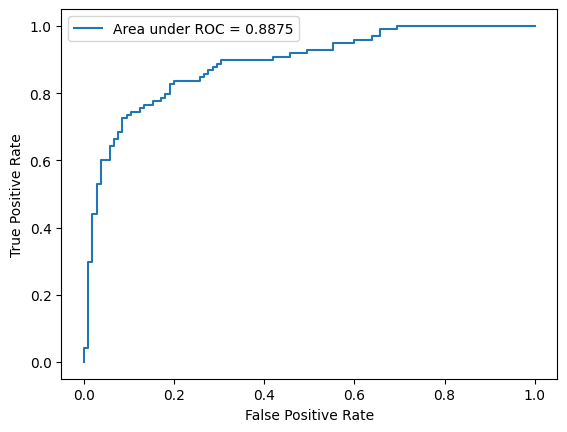

In [ ]:
# plot the roc curve
fpr, tpr, _ = roc_curve(y_label, y_score)
plt.plot(fpr, tpr, label = "Area under ROC = {:.4f}".format(roc_score))
plt.legend(loc = 'best')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

## 평가 지표 상세 분석
*   정확도 (Accuracy) 80.3%: 이제 모델이 더 이상 맹목적으로 'Non-COVID'라고 찍지 않고, 두 가지 클래스의 차이를 명확히 구분하며 정상적으로 학습을 수행하고 있습니다. 의료 이미지라는 까다로운 도메인에서 80% 선을 돌파한 것은 훌륭한 마일스톤.

*   민감도 (Sensitivity) 78.6%: 실제 COVID 양성인 환자 중 약 79%를 정확히 찾아냈습니다! 2%에서 79%로 끌어올린 이 지표가 이번 융합 모델이 만들어낸 가장 값진 성과입니다.

*   특이도 (Specificity) 81.9%: 정상(Non-COVID) 데이터 또한 약 82%의 확률로 정확히 걸러내고 있습니다. 민감도와 특이도의 편차가 크지 않아, 모델이 한쪽 클래스에 편향되지 않고 균형(Balance)을 아주 잘 잡았습니다.

*   ROC Score 0.887: 1.0 만점에 0.887을 기록했습니다. 0.9에 근접한 수치로, 이 모델의 COVID/Non-COVID 분류 능력이 우수하다는 것을 수학적으로 증명합니다.

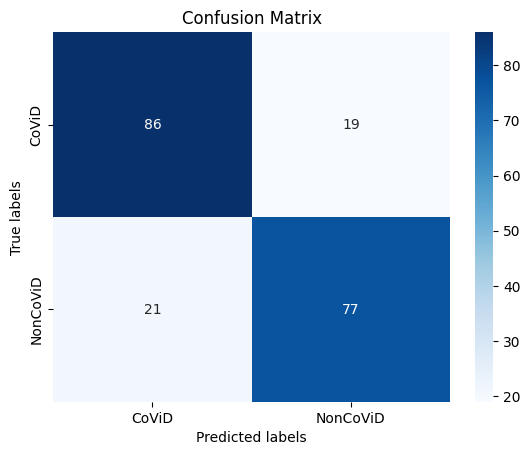

In [ ]:
import seaborn as sns

conf_matrix = conf_matrix
ax= plt.subplot()
sns.heatmap(conf_matrix, annot=True, ax = ax, cmap = 'Blues'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['CoViD', 'NonCoViD']); ax.yaxis.set_ticklabels(['CoViD', 'NonCoViD']);

## 의료 인공지능 기반 진단 결과
*   민감도(Sensitivity)의 상승: 놀랍게도 테스트 셋에서는 실제 코로나 환자 105명(86+19) 중 86명을 맞추어 민감도가 81.9%로 검증 때보다 오히려 상승했습니다.

*   특이도(Specificity)의 안정성: 실제 정상인 98명(77+21) 중 77명을 맞추어 특이도는 78.6%를 기록했습니다.

*   보완해야 할 치명적 약점 (19명의 위음성): 의료 데이터 분석에서 가장 주의 깊게 봐야 할 숫자는 바로 19(False Negative)입니다. 이 19명은 실제 코로나에 걸렸지만 모델이 정상이라고 판단하여 집으로 돌려보낸 환자들입니다. 바이러스 전파나 환자의 예후 악화를 생각하면 이 숫자를 줄이는 것이 실무 도입의 핵심 과제입니다.

*   현재 모델은 COVID일 확률이 50%를 넘을 때만 양성(COVID)으로 판정하도록 설정되어 있습니다. 저 19명의 놓친 환자를 살리기 위해, 판단 기준선(Threshold)을 30%나 40%로 낮춰서 "조금만 의심스러워도 일단 양성으로 판정하여 의사의 정밀 검사를 유도하는" 임계값 조정 기법을 적용할 수 있을 듯.